### 2.2.1 베이스라인 구현을 위한 설정

먼저 간단하게 데이터 살펴보고

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/jj.csv")
df.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


In [3]:
df.tail()

,date,data
79,1979-10-01,9.99
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02
83,1980-10-01,11.61


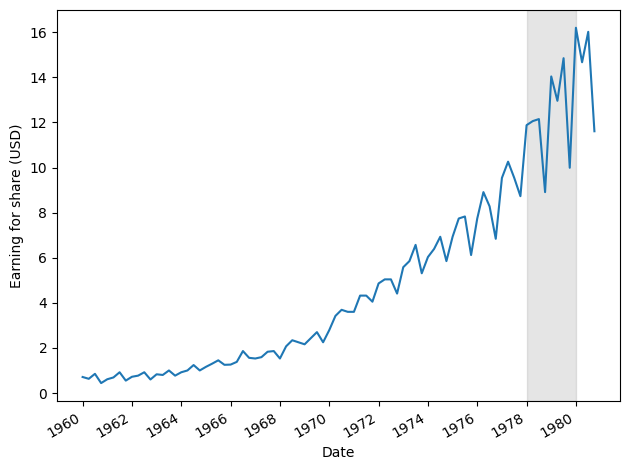

In [4]:
fig, ax = plt.subplots()

ax.plot(df["date"], df["data"])
ax.set_xlabel("Date")
ax.set_ylabel("Earning for share (USD)")
ax.axvspan(80, 72, color="#808080", alpha=0.2)

plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
fig.tight_layout()

plt.savefig("figures/ch02_f01_peixeiro.png", dpi=300)

훈련과 테스트로 데이터 나누기

In [5]:
train = df[:-4]
test = df[-4:] 

## 2.2.2 평균 기반 베이스라인 모델

In [6]:
historical_mean = np.mean(train["data"])
historical_mean

np.float64(4.308499987499999)

In [7]:
# 데이터프레임 test에 pred_mean 컬럼을 만들면서 historical_mean을 배치...loc은 label로 접근
test.loc[:, "pred_mean"] = historical_mean
test

,date,data,pred_mean
80,1980-01-01,16.20,4.3085
81,1980-04-01,14.67,4.3085
82,1980-07-02,16.02,4.3085
83,1980-10-01,11.61,4.3085


In [8]:
# 평균 절대 백분율 오차(Mean Absolute Percentage Error, MAPE)
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [9]:
mape_hist_mean = mape(test["data"], test["pred_mean"])
mape_hist_mean

np.float64(70.00752579965119)

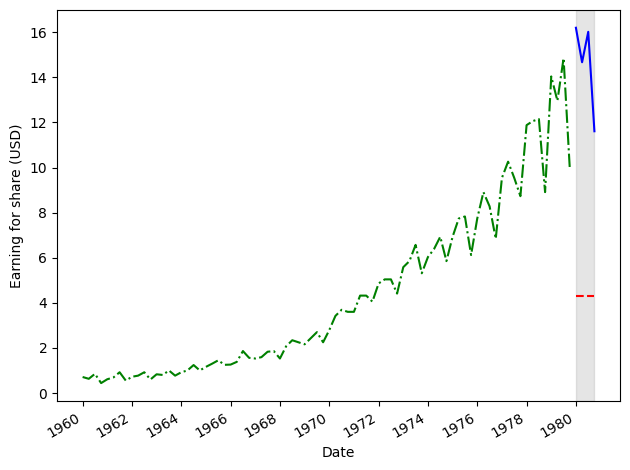

In [10]:
fig, ax = plt.subplots()

# 1960~79 데이터, 녹색 1점쇄선
ax.plot(train["date"], train["data"], "g-.", label="Train")
# 1980년 데이터, 파란 실선
ax.plot(test["date"], test["data"], "b-", label="Test")
# 예측값으로 80년에 수평으로 빨간색 점선
ax.plot(test["date"], test["pred_mean"], "r--", label="Predicted")

ax.set_xlabel("Date")
ax.set_ylabel("Earning for share (USD)")
# 수직 구간 색으로 구분, xmin, xmax, 색, 투명도 설정
ax.axvspan(80, 83, color="#808080", alpha=0.2)

# 0~85까지 8 단위로 x축 눈금을 만들고, 그 중에 1960~1980 라벨링?
plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

# x축이 날자 형식일 때 눈금 레이블을 조정
fig.autofmt_xdate()
# 여백을 줄이나?
fig.tight_layout()

plt.savefig("figures/ch02_f06_peixeiro.png", dpi=300)

# 2.3 작년의 평균으로 예측하기

In [11]:
last_year_mean = np.mean(train.data[-4:])
last_year_mean

np.float64(12.96)

In [12]:
test.loc[:, "pred_last_yr_mean"] = last_year_mean
mape_last_year_mean = mape(test["data"], test["pred_last_yr_mean"])
mape_last_year_mean

np.float64(15.5963680725103)

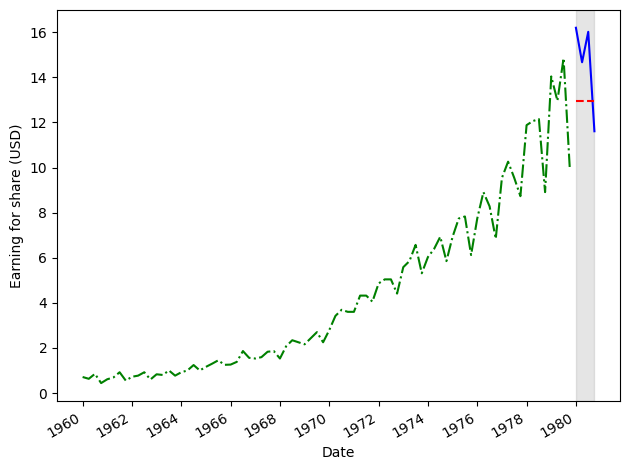

In [13]:
fig, ax = plt.subplots()

# 1960~79 데이터, 녹색 1점쇄선
ax.plot(train["date"], train["data"], "g-.", label="Train")
# 1980년 데이터, 파란 실선
ax.plot(test["date"], test["data"], "b-", label="Test")
# 예측값으로 80년에 수평으로 빨간색 점선
ax.plot(test["date"], test["pred_last_yr_mean"], "r--", label="Predicted")

ax.set_xlabel("Date")
ax.set_ylabel("Earning for share (USD)")
# 수직 구간 색으로 구분, xmin, xmax, 색, 투명도 설정
ax.axvspan(80, 83, color="#808080", alpha=0.2)

# 0~85까지 8 단위로 x축 눈금을 만들고, 그 중에 1960~1980 라벨링?
plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

# x축이 날자 형식일 때 눈금 레이블을 조정
fig.autofmt_xdate()
# 여백을 줄이나?
fig.tight_layout()

plt.savefig("figures/ch02_f07_peixeiro.png", dpi=300)

# 2.4 마지막으로 측정된 값으로 예측하기

In [14]:
last = train["data"].iloc[-1]
last

np.float64(9.99)

In [15]:
test.loc[:, "pred_last"] = last
test

,date,data,pred_mean,pred_last_yr_mean,pred_last
80,1980-01-01,16.20,4.3085,12.96,9.99
81,1980-04-01,14.67,4.3085,12.96,9.99
82,1980-07-02,16.02,4.3085,12.96,9.99
83,1980-10-01,11.61,4.3085,12.96,9.99


In [16]:
mape_last = mape(test["data"], test["pred_last"])
mape_last

np.float64(30.457277908606535)

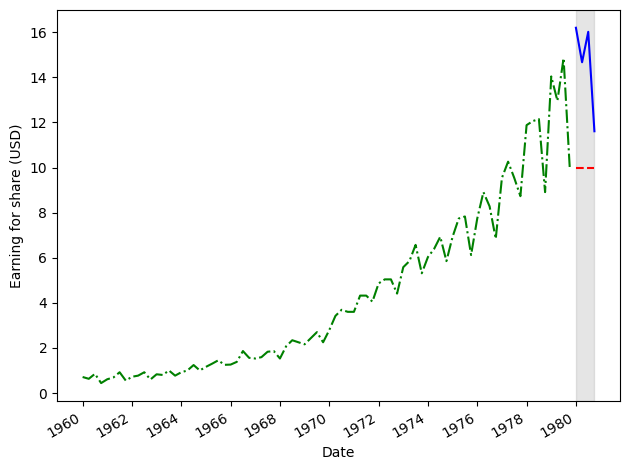

In [17]:
fig, ax = plt.subplots()

# 1960~79 데이터, 녹색 1점쇄선
ax.plot(train["date"], train["data"], "g-.", label="Train")
# 1980년 데이터, 파란 실선
ax.plot(test["date"], test["data"], "b-", label="Test")
# 예측값으로 80년에 수평으로 빨간색 점선
ax.plot(test["date"], test["pred_last"], "r--", label="Predicted")

ax.set_xlabel("Date")
ax.set_ylabel("Earning for share (USD)")
# 수직 구간 색으로 구분, xmin, xmax, 색, 투명도 설정
ax.axvspan(80, 83, color="#808080", alpha=0.2)

# 0~85까지 8 단위로 x축 눈금을 만들고, 그 중에 1960~1980 라벨링?
plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

# x축이 날자 형식일 때 눈금 레이블을 조정
fig.autofmt_xdate()
# 여백을 줄이나?
fig.tight_layout()

plt.savefig("figures/ch02_f08_peixeiro.png", dpi=300)

# 2.5 단순한 계절적 예측

In [20]:
# 1980년도 pred_last_season 값은 1960~79년도까지 자료의 마지막, 즉 79년도 마지막 4개 자료...
test.loc[:, "pred_last_season"] = train["data"][-4:].values
test

,date,data,pred_mean,pred_last_yr_mean,pred_last,perd_last_season,pred_last_season
80,1980-01-01,16.20,4.3085,12.96,9.99,14.04,14.04
81,1980-04-01,14.67,4.3085,12.96,9.99,12.96,12.96
82,1980-07-02,16.02,4.3085,12.96,9.99,14.85,14.85
83,1980-10-01,11.61,4.3085,12.96,9.99,9.99,9.99


In [21]:
mape_navice_seasonal = mape(test["data"], test["pred_last_season"])
mape_navice_seasonal

np.float64(11.561658552433654)

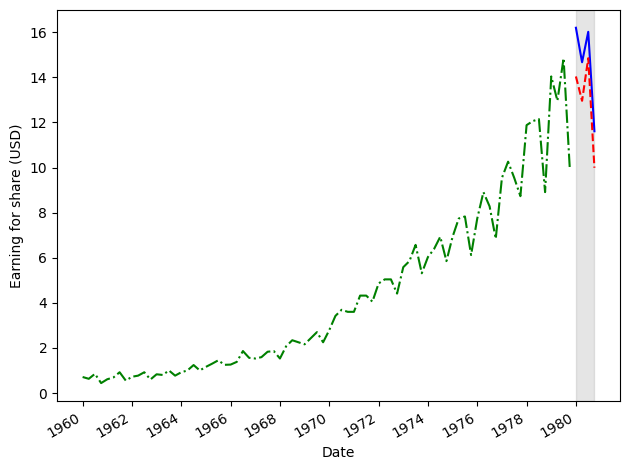

In [22]:
fig, ax = plt.subplots()

# 1960~79 데이터, 녹색 1점쇄선
ax.plot(train["date"], train["data"], "g-.", label="Train")
# 1980년 데이터, 파란 실선
ax.plot(test["date"], test["data"], "b-", label="Test")
# 예측값으로 80년에 수평으로 빨간색 점선
ax.plot(test["date"], test["pred_last_season"], "r--", label="Predicted")

ax.set_xlabel("Date")
ax.set_ylabel("Earning for share (USD)")
# 수직 구간 색으로 구분, xmin, xmax, 색, 투명도 설정
ax.axvspan(80, 83, color="#808080", alpha=0.2)

# 0~85까지 8 단위로 x축 눈금을 만들고, 그 중에 1960~1980 라벨링?
plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

# x축이 날자 형식일 때 눈금 레이블을 조정
fig.autofmt_xdate()
# 여백을 줄이나?
fig.tight_layout()

plt.savefig("figures/ch02_f09_peixeiro.png", dpi=300)

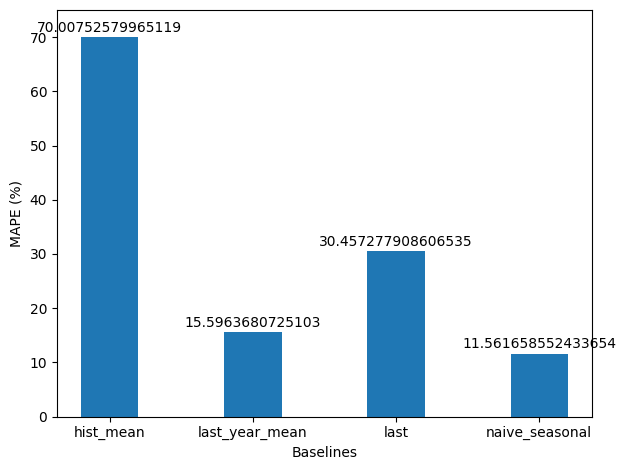

In [23]:
fig, ax = plt.subplots()

x = ["hist_mean", "last_year_mean", "last", "naive_seasonal"]
y = [mape_hist_mean, mape_last_year_mean, mape_last, mape_navice_seasonal]

ax.bar(x, y, width=0.4)
ax.set_xlabel("Baselines")
ax.set_ylabel("MAPE (%)")
ax.set_ylim(0, 75)

for index, value in enumerate(y):
    plt.text(x=index, y=value + 1, s=str(value), ha="center")

plt.tight_layout()
plt.savefig("figures/ch02_f10_peixeiro.png", dpi=300)